# Evaluate the UVLF + CMB likelihood for ONE set of 9 parameters

This notebook evaluates exactly what `mcmc_uvlf_9params.py` computes for a single point:
the CLASS P(k), the UVLF/QHI model, the reionization history fed into CLASS, the Planck
2018 lowl TT/EE and highl TTTEEE lite likelihoods, and the derived `tau_e`.

**To use:** edit the parameter values in the `POINT` cell below, then run all cells.

**Fixed in the run** (not free, same as the MCMC): `H0 = 67.4`, `omega_b = 0.0224`,
`omega_cdm = 0.120`. The free params are the 9 astrophysics ones, plus `n_s`,`logA`.

In [1]:
import os, sys, copy
import numpy as np
#change according to your path, if downloaded from github only change the line below to match your project directory
PROJECT = "/home/aayush/testing_bench"          
DATA_DIR = os.path.join(PROJECT, "data_files")
sys.path.insert(0, PROJECT)
os.chdir(DATA_DIR)  
print("cwd:", os.getcwd())

cwd: /home/aayush/testing_bench/data_files


In [2]:
import mcmc_uvlf_9params as mcmcmod
from cobaya.model import get_model

info = copy.deepcopy(mcmcmod.info)
info.pop("output", None)
info.pop("resume", None)
info.pop("sampler", None)   # no MCMC here

model = get_model(info)
derived_names = list(model.parameterization.derived_params().keys())
print("derived params:", derived_names)
print("likelihoods:", list(model.likelihood.keys()))
print("model ready.")

[classy_reio] `classy` module loaded successfully from /home/aayush/.local/lib/python3.14/site-packages
[planck_2018_highl_plik.ttteee_lite] `clipy` module loaded successfully from /home/aayush/testing_bench/cobaya_packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/home/aayush/testing_bench/cobaya_packages/data/planck_2018/baseline/plc_3.0/hi_l/plik_lite/plik_lite_v22_TTTEEE.clik' on test data. got -292.286 expected -292.286 (diff -3.86314e-09)
----
before crop : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
after crop  : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
derived params: ['A_s', 'tau_e', 'chi2__CMB']
likelihoods: ['uvlf', 'planck_2018_lowl.TT', 'planck_2018_lowl.EE', 'planck_2018_highl_plik.TTTEEE_lite']
model ready.


## Set the parameter point

Edit the values below. `lsum, ldiff, l2, l3` describe the redshift evolution of
`log10 f_star,10/c_star`; `asum, adiff, log10_fesc10, alpha_esc, log10Mcrit` the other
astrophysics; `n_s`, `logA` the cosmology (priors as in the MCMC).

In [7]:
POINT = {
    # astro params
    "lsum": -0.902196,
    "ldiff": -1.20594,
    "l2": 10.3442,
    "l3": 0.677975,
    "asum": 0.512237,
    "adiff": 0.342735,
    "log10_fesc10": -0.834616,
    "alpha_esc": -0.338567,
    "log10Mcrit": 9.19371,
    # cosmo params
    "n_s": 0.943396,
    "logA": 3.32225,
    # H0 / omega_b / omega_cdm are FIXED in the run (67.4 / 0.0224 / 0.120)
}

In [9]:
res = model.logposterior(POINT, return_derived=True)
dvals = res.derived if isinstance(res.derived, dict) else dict(zip(derived_names, res.derived))

# per-likelihood logL -> chi2 (order follows model.likelihood.keys())
lik_names = list(model.likelihood.keys())
loglikes = {n: float(v) for n, v in zip(lik_names, res.loglikes)}
chi = {n: -2.0 * v for n, v in loglikes.items()}

print("=" * 62)
print(f"log-prior      = {res.logprior:+.4f}")
print(f"log-likelihood = {res.loglike:+.4f}")
print(f"log-posterior  = {res.logpost:+.4f}")
print("-" * 62)
print(f"{'component':<34}{'logL':>10}{'chi2':>12}")
for n in loglikes:
    print(f"{n:<34}{loglikes[n]:+.4f}{chi[n]:12.3f}")
print("-" * 62)
print(f"{'UVLF':<30}{'':<10}{chi['uvlf']:12.3f}")
cmb = sum(v for k, v in chi.items() if k.startswith('planck'))
print(f"{'Total':<30}{'':<10}{cmb:12.3f}")
print("=" * 62)
print(f"tau_e  = {dvals['tau_e']:.6f}")
print(f"A_s    = {dvals['A_s']:.6e}")
if 'chi2__CMB' in dvals:
    print(f"chi2__CMB = {dvals['chi2__CMB']:.3f}")


log-prior      = -11.2569
log-likelihood = -557.4360
log-posterior  = -568.6929
--------------------------------------------------------------
component                               logL        chi2
uvlf                              -25.4383      50.877
planck_2018_lowl.TT               -11.2272      22.454
planck_2018_lowl.EE               -198.5019     397.004
planck_2018_highl_plik.TTTEEE_lite-322.2686     644.537
--------------------------------------------------------------
UVLF                                          50.877
Total                                       1063.995
tau_e  = 0.059308
A_s    = 2.772266e-09
chi2__CMB = 1063.995


### Reionization history that was sent to CLASS (`x_e` vs `z`)

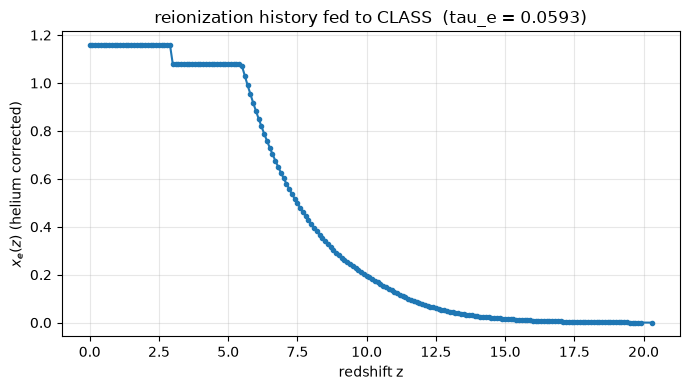

In [ ]:
import matplotlib.pyplot as plt

st = model.theory["uvlf_reio"].current_state
z = np.array([float(v) for v in st["reio_inter_z"].split(",")])
xe = np.array([float(v) for v in st["reio_inter_xe"].split(",")])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, xe, "-o", ms=3)
ax.set_xlabel("redshift z")
ax.set_ylabel(r"$x_e(z)$")
ax.set_title(f"reionization history fed to CLASS  (tau_e = {dvals['tau_e']:.4f})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### QHI(z) curve and UVLF vs QHI chi^2

Rebuilds the P(k) once (same CLASS settings as the MCMC) and evaluates the model
directly, to check the reionization curve and how the astro chi^2 splits into the
UVLF and QHI parts.

chi2_UVLF =   159.912
chi2_QHI  =    11.624
total     =   171.536   (matches astro chi2 above: 171.536)


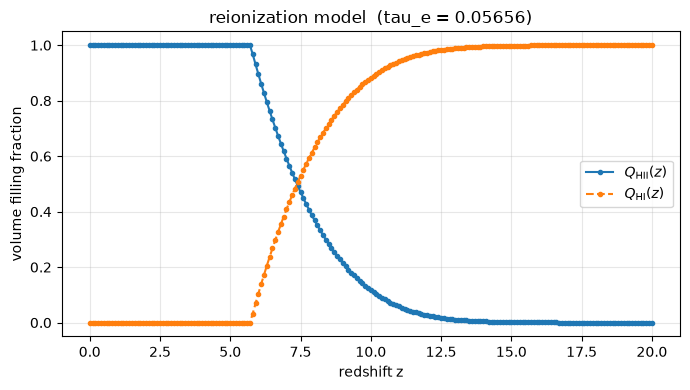

In [6]:
from classy import Class
import reion_uvlf_9params as uvlf
from reion_uvlf_funcs import model_and_data_allUVLF, model_and_data_QHI, get_chisq

# same P(k) build as mcmc_uvlf_9params.UVLFReio.calculate
H0, wb, wc = 67.4, 0.0224, 0.120
h = H0 / 100.0
om = (wc + wb) / h**2
ol = 1.0 - om
ob = wb / h**2
pk = Class()
pk.set({"output": "mPk", "P_k_max_1/Mpc": 100.0, "z_max_pk": 1.0,
        "k_per_decade_for_pk": 20, "H0": H0, "omega_b": wb,
        "omega_cdm": wc, "n_s": POINT["n_s"],
        "A_s": 1e-10 * np.exp(POINT["logA"])})
pk.compute()
kk = np.logspace(-4, np.log10(100), 500)
Pk0 = np.array([pk.pk_lin(k, 0.0) for k in kk])
pk.struct_cleanup()
lnk = np.log(kk / h)
lnpk = np.log(Pk0 * h**3)

logl, dmod = uvlf.log_likelihood(
    POINT["lsum"], POINT["ldiff"], POINT["l2"], POINT["l3"],
    POINT["asum"], POINT["adiff"], POINT["log10_fesc10"],
    POINT["alpha_esc"], POINT["log10Mcrit"],
    lnk, lnpk, om, ol, h, ob, YHe=0.24)

cdict = {"omega_M_0": om, "omega_b_0": ob, "h": h,
         "YHe": 0.24, "omega_L_0": ol}
model_q, data_q, sig_q = model_and_data_allUVLF(
    [], POINT["log10Mcrit"], POINT["lsum"], POINT["ldiff"],
    POINT["l2"], POINT["l3"], POINT["asum"], POINT["adiff"],
    POINT["l2"], POINT["l3"], POINT["log10_fesc10"],
    POINT["alpha_esc"], lnk, lnpk, cdict)
chi_uvlf = get_chisq(model_q, data_q, sig_q)
model_r, data_r, sig_r = model_and_data_QHI(dmod["z_arr"], dmod["QHII_arr"])
chi_qhi = get_chisq(model_r, data_r, sig_r)

print(f"chi2_UVLF = {chi_uvlf:9.3f}")
print(f"chi2_QHI  = {chi_qhi:9.3f}")
print(f"total     = {chi_uvlf + chi_qhi:9.3f}   (matches astro chi2 above: {-2*logl:.3f})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dmod["z_arr"], dmod["QHII_arr"], "-o", ms=3, label=r"$Q_{\rm HII}(z)$")
ax.plot(dmod["z_arr"], 1 - dmod["QHII_arr"], "--o", ms=3, label=r"$Q_{\rm HI}(z)$")
ax.set_xlabel("redshift z")
ax.set_ylabel("volume filling fraction")
ax.set_title(f"reionization model  (tau_e = {dmod['tau_e']:.5f})")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()